✅ Dataset Shape: Inputs = (256, 20), Outputs = (256,)

=== 16-to-1 MULTIPLEXER using MLP ===
Accuracy: 1.0000

Confusion Matrix:
 [[240   0]
 [  0  16]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       240
           1       1.00      1.00      1.00        16

    accuracy                           1.00       256
   macro avg       1.00      1.00      1.00       256
weighted avg       1.00      1.00      1.00       256



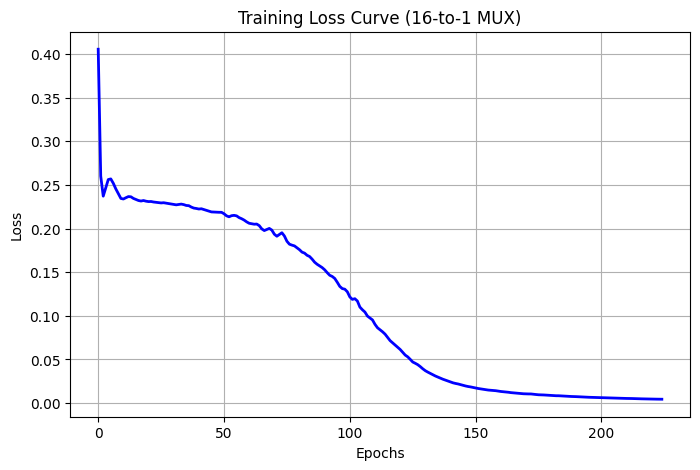

In [1]:
# mux_16to1_mlp.py
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import joblib
import os

# ======================================================
# 1️⃣ Define the 16-to-1 Multiplexer Dataset
# ======================================================
# Inputs: 16 data bits (D0–D15) + 4 select bits (S3–S0)
# Output: 1 bit (Y = D[select])
X = []
y = []

for sel in range(16):  # 4-bit selector (0–15)
    sel_bits = [int(x) for x in format(sel, '04b')]
    for d_index in range(16):  # 16 possible high inputs
        data_bits = [0] * 16
        data_bits[d_index] = 1  # One line high at a time
        # Output = D[selected line]
        Y = data_bits[sel]
        X.append(data_bits + sel_bits)  # combine data + select
        y.append(Y)

X = np.array(X, dtype=int)
y = np.array(y, dtype=int)

print(f"✅ Dataset Shape: Inputs = {X.shape}, Outputs = {y.shape}")

# ======================================================
# 2️⃣ Train the MLP Model
# ======================================================
model = MLPClassifier(hidden_layer_sizes=(32, 16), activation='tanh',
                      solver='adam', learning_rate_init=0.01,
                      max_iter=3000, random_state=42)

model.fit(X, y)

# ======================================================
# 3️⃣ Evaluate the Model
# ======================================================
y_pred = model.predict(X)
acc = accuracy_score(y, y_pred)

print("\n=== 16-to-1 MULTIPLEXER using MLP ===")
print(f"Accuracy: {acc:.4f}")
print("\nConfusion Matrix:\n", confusion_matrix(y, y_pred))
print("\nClassification Report:\n", classification_report(y, y_pred, zero_division=0))

# ======================================================
# 5️⃣ Plot Training Loss
# ======================================================
plt.figure(figsize=(8, 5))
plt.plot(model.loss_curve_, color='blue', linewidth=2)
plt.title("Training Loss Curve (16-to-1 MUX)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid(True)
plt.show()


In [2]:
import joblib
joblib.dump(model, "frontend/models/16to1_MUX_mlp.pkl")

['frontend/models/16to1_MUX_mlp.pkl']